# Credit ScoreCard con variable ESG

In [1]:
import pandas as pd
import numpy as np
import scorecardpy as sc
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
SZ = dict(width=600, height=600)

C:\Users\rolg0\anaconda3\envs\Main\Lib\site-packages\scorecardpy\germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 0. Creación de variable ESG

In [2]:
df = pd.read_csv(r"C:\Users\rolg0\Downloads\8vo semestre\Administración Integral de Riesgos\base_credito2.csv")
df.head()

,ID,Edad,Ingreso_Mensual,Antiguedad_Laboral,Linea_Credito,Utilizacion_Credito,Historial_Atrasos,Num_Tarjetas,Tipo_Empleo,Sexo,...,Dependientes,Score_Buro,Num_Creditos_Activos,Morosidad_12m,Num_Consultas_Buro,Region,Cambio_Domicilio,Pago_Minimo,Cuota_Al_Ingreso,Default
0,1,33,25079,23.8,124679.0,0.24,1,5,Formal,M,...,4,607,3,0,4,Sur,1,0.02,0.26,0
1,2,59,34848,6.9,87360.0,0.70,2,2,Formal,F,...,0,719,4,0,8,Sur,0,0.01,0.68,1
2,3,39,15350,22.6,45295.0,0.94,2,5,Formal,M,...,3,667,0,0,0,Norte,0,0.78,0.68,1
3,4,64,14704,4.4,110146.0,0.23,1,4,Independiente,F,...,2,665,5,0,0,Centro,1,0.58,0.13,1
4,5,67,20523,28.0,17450.0,0.75,1,4,Independiente,F,...,0,786,8,0,6,Sur,1,0.93,0.66,1


In [3]:
df["Ciudad"].head(100)

0      GDL
1     CDMX
2      GDL
3      GDL
4      MER
      ... 
95     PUE
96     PUE
97     PUE
98     PUE
99     TIJ
Name: Ciudad, Length: 100, dtype: object

In [4]:
#Cargamos excel de la CNBV
ruta_cnbv = r"C:\Users\rolg0\Downloads\8vo semestre\Administración Integral de Riesgos\Base_de_Datos_de_Inclusion_Financiera_202506.xlsx"
df_cnbv_sexo = pd.read_excel(ruta_cnbv, sheet_name='BD por sexo Banca Mun', skiprows=11)
df_cnbv_sexo.columns = [c.replace('\n', ' ') for c in df_cnbv_sexo.columns]
df_cnbv_sexo[['Estado', 'Municipio']].head()

,Estado,Municipio
0,Aguascalientes,Aguascalientes
1,Aguascalientes,Asientos
2,Aguascalientes,Calvillo
3,Aguascalientes,Cosío
4,Aguascalientes,Jesús María


In [5]:
# Columnas de contratos por sexos
col_muj_cred = 'Total Número de créditos Mujeres'
col_hom_cred = 'Total Número de créditos Hombres'

# Homologar CDMX
df_cnbv_sexo['Estado'] = df_cnbv_sexo['Estado'].replace({'Ciudad de México': 'CDMX', 'Distrito Federal': 'CDMX'})
df_cnbv_sexo.loc[df_cnbv_sexo['Estado'] == 'CDMX', 'Municipio'] = 'CDMX'

# Agrupación
df_grouped = df_cnbv_sexo.groupby(['Municipio']).agg({ col_muj_cred: 'sum', col_hom_cred: 'sum'}).reset_index()

# Cálculo de índice 
df_grouped['Indice_Social_CNBV'] = (df_grouped[col_muj_cred] /(df_grouped[col_muj_cred] + df_grouped[col_hom_cred])).fillna(0)

df_social_ready = df_grouped[['Municipio', 'Indice_Social_CNBV']]

In [7]:
# Diccionario de ciudades
diccionario = {
    'GDL': 'Guadalajara',
    'CDMX': 'CDMX', 
    'PUE': 'Puebla',
    'MER': 'Mérida',
    'MTY': 'Monterrey',
    'TIJ': 'Tijuana'
}

# Creamos la columna de unión con el df original
df['Municipio_Union'] = df['Ciudad'].map(diccionario)
df_final = pd.merge(df, df_social_ready, left_on='Municipio_Union', right_on='Municipio', how='left')
df_final = df_final.drop(columns=['Municipio_Union', 'Municipio'])
df_final[['ID', 'Ciudad', 'Indice_Social_CNBV']].head()

,ID,Ciudad,Indice_Social_CNBV
0,1,GDL,0.483873
1,2,CDMX,0.474030
2,3,GDL,0.483873
3,4,GDL,0.483873
4,5,MER,0.495663


In [8]:
#Exportar a un archivo de excel
ruta_salida = r"C:\Users\rolg0\Downloads\8vo semestre\Administración Integral de Riesgos\base_social.xlsx"

with pd.ExcelWriter(ruta_salida) as writer:
    df_final.to_excel(writer, sheet_name='Base_Datos', index=False)

## 1. Carga y división

In [9]:
df = pd.read_excel(r'C:\Users\rolg0\Downloads\8vo semestre\Administración Integral de Riesgos\base_social.xlsx')

for col in ['Sexo','Estado_Civil','Ciudad','Tipo_Empleo','Escolaridad','Region']:
    df[col] = df[col].astype(str)

train, test = train_test_split(df, test_size=0.3, random_state=123)

print(df['Default'].value_counts(normalize=True).round(4))
print(f'Train: {len(train):,} | Test: {len(test):,}')

Default
1    0.8363
0    0.1637
Name: proportion, dtype: float64
Train: 70,000 | Test: 30,000


## 2. IV y selección de variables

In [11]:
cols = [c for c in train.columns if c not in ['Default','ID']]
iv   = sc.iv(train[cols + ['Default']], y='Default').sort_values('info_value', ascending=False)
print(iv.to_string(index=False))

vars_base = iv[iv['info_value'] > 0.02]['variable'].tolist()
vars_esg  = vars_base.copy()
if 'Indice_Social_CNBV' not in vars_esg:
    vars_esg.append('Indice_Social_CNBV')

print(f'\nBase ({len(vars_base)} vars): {vars_base}')
print(f'ESG  ({len(vars_esg)} vars): {vars_esg}')

            variable   info_value
     Ingreso_Mensual 3.740830e-01
      Ingresos_Extra 2.936888e-01
       Morosidad_12m 2.375174e-01
                Edad 1.745428e-01
 Utilizacion_Credito 1.435394e-01
       Linea_Credito 9.804490e-02
          Score_Buro 5.500922e-02
  Antiguedad_Laboral 2.988793e-02
   Historial_Atrasos 1.974062e-02
         Pago_Minimo 1.198383e-02
    Cuota_Al_Ingreso 8.783155e-03
  Num_Consultas_Buro 1.161847e-03
Num_Creditos_Activos 6.591785e-04
        Num_Tarjetas 6.170884e-04
        Dependientes 5.493469e-04
         Escolaridad 5.122252e-04
         Tipo_Empleo 4.196211e-04
  Indice_Social_CNBV 3.894508e-04
              Ciudad 3.894508e-04
        Estado_Civil 3.557729e-04
              Region 2.065469e-04
    Cambio_Domicilio 7.250546e-05
                Sexo 9.619637e-06
          Tiene_Casa 1.468954e-06
          Tiene_Auto 3.860398e-09

Base (8 vars): ['Ingreso_Mensual', 'Ingresos_Extra', 'Morosidad_12m', 'Edad', 'Utilizacion_Credito', 'Linea_Credito

## 3. WOE Binning

In [12]:
# BASE
bins_base = sc.woebin(train[vars_base + ['Default']], y='Default',stop_limit=0.1, bin_num_limit=3)

# ESG
bins_esg = sc.woebin(train[vars_esg + ['Default']], y='Default', stop_limit=0.1, bin_num_limit=3)

# Transformación
train_base = sc.woebin_ply(train, bins_base)
test_base  = sc.woebin_ply(test, bins_base)

train_esg  = sc.woebin_ply(train, bins_esg)
test_esg   = sc.woebin_ply(test, bins_esg)

woe_base = [c for c in train_base.columns if c.endswith('_woe')]
woe_esg  = [c for c in train_esg.columns if c.endswith('_woe')]

[INFO] creating woe binning ...
Binning on 70000 rows and 9 columns in 00:00:14
[INFO] creating woe binning ...
Binning on 70000 rows and 10 columns in 00:00:15
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] converting into woe values ...


In [13]:
# Detección y corrección de variables monotónicas
def verificar_monotonicidad(bins):
    resultados = {}
    for var, df in bins.items():
        woe = df['woe'].values
        diff = np.diff(woe)
        creciente = np.all(diff >= 0)
        decreciente = np.all(diff <= 0)

        resultados[var] = creciente or decreciente

    return pd.Series(resultados)
    
def corregir_monotonicidad(bins, train, y='Default'):
    mono = verificar_monotonicidad(bins)
    vars_no_monotonas = mono[~mono].index.tolist()
    if len(vars_no_monotonas) > 0:
        bins_fix = sc.woebin(train,y=y,x=vars_no_monotonas,stop_limit=0.1, bin_num_limit=2)
        for var in vars_no_monotonas:
            bins[var] = bins_fix[var]
    mono_final = verificar_monotonicidad(bins)
    return bins, mono_final

# Base
bins_base, mono_base = corregir_monotonicidad(bins_base, train)
# ESG
bins_esg, mono_esg = corregir_monotonicidad(bins_esg, train)

print("Variables Base Monotonas:")
print(mono_base)

print("Variables ESG Monotomas:")
print(mono_esg)


[INFO] creating woe binning ...
[INFO] creating woe binning ...
Variables Base Monotonas:
Antiguedad_Laboral     True
Linea_Credito          True
Edad                   True
Score_Buro             True
Ingreso_Mensual        True
Utilizacion_Credito    True
Ingresos_Extra         True
Morosidad_12m          True
dtype: bool
Variables ESG Monotomas:
Indice_Social_CNBV     True
Antiguedad_Laboral     True
Linea_Credito          True
Edad                   True
Score_Buro             True
Ingreso_Mensual        True
Utilizacion_Credito    True
Ingresos_Extra         True
Morosidad_12m          True
dtype: bool


## 4. Entrenamiento

In [14]:
y_train = train_base['Default']
y_test  = test_base['Default']

m_base = LogisticRegression(max_iter=1000, class_weight='balanced', penalty='l2', C=0.5)
m_base.fit(train_base[woe_base], y_train)

m_esg = LogisticRegression(max_iter=1000, class_weight='balanced')
m_esg.fit(train_esg[woe_esg], y_train)

prob_base = m_base.predict_proba(test_base[woe_base])[:, 1]
prob_esg  = m_esg.predict_proba(test_esg[woe_esg])[:, 1]

print(f'AUC Base: {roc_auc_score(y_test, prob_base):.4f}')
print(f'AUC ESG:  {roc_auc_score(y_test, prob_esg):.4f}')

AUC Base: 0.7068
AUC ESG:  0.7067


## 5. Curvas ROC

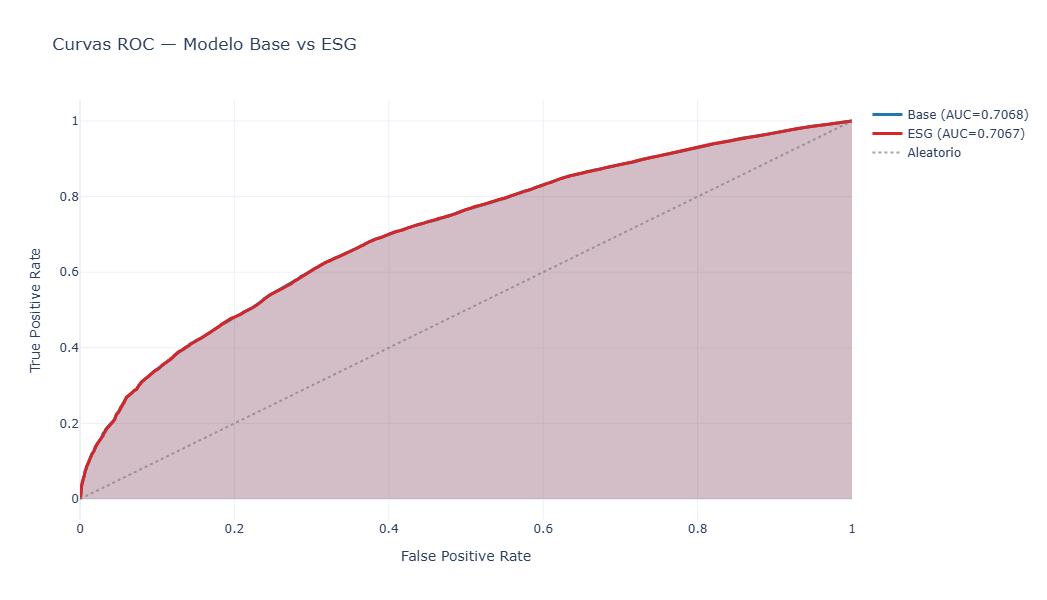

In [15]:
fig = go.Figure()

for nombre, probs, color, fillcolor in [
    ('Base', prob_base, '#1f77b4', 'rgba(31,119,180,0.2)'),
    ('ESG', prob_esg, '#d62728', 'rgba(214,39,40,0.2)')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)

    # Curva
    fig.add_trace(go.Scatter(
        x=fpr, y=tpr,
        mode='lines',
        name=f'{nombre} (AUC={auc:.4f})',
        line=dict(color=color, width=3)
    ))

    # Área bajo la curva
    fig.add_trace(go.Scatter(
        x=fpr, y=tpr,
        fill='tozeroy',
        mode='none',
        fillcolor=fillcolor,
        showlegend=False
    ))

# Línea aleatoria
fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1],
    mode='lines',
    name='Aleatorio',
    line=dict(color='gray', dash='dot', width=2),
    opacity=0.7
))

fig.update_layout(
    title='Curvas ROC — Modelo Base vs ESG',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    template='plotly_white',
    width=900,
    height=600
)

fig.show()

## 6. Matrices de confusión

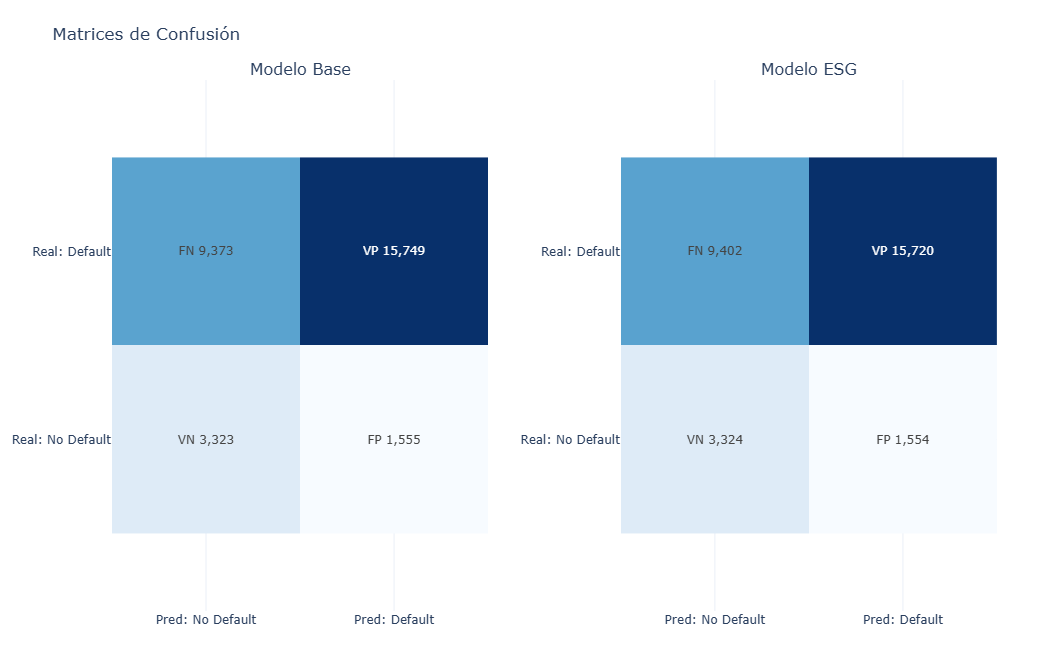

In [21]:
fpr, tpr, thresholds = roc_curve(y_test, prob_base)
ks = tpr - fpr
umbral = thresholds[np.argmax(ks)]

fig = make_subplots(rows=1, cols=2, subplot_titles=['Modelo Base', 'Modelo ESG'], horizontal_spacing=0.15)

for i, (nombre, probs) in enumerate([('Base', prob_base), ('ESG', prob_esg)], 1):
    preds = (probs >= umbral).astype(int)
    cm = confusion_matrix(y_test, preds)

    labels = [[f'VN\n{cm[0,0]:,}', f'FP\n{cm[0,1]:,}'],
              [f'FN\n{cm[1,0]:,}', f'VP\n{cm[1,1]:,}']]

    fig.add_trace(go.Heatmap(
        z=cm,
        x=['Pred: No Default', 'Pred: Default'],
        y=['Real: No Default', 'Real: Default'],
        text=labels,
        texttemplate="%{text}",
        textfont={"size": 12},
        colorscale='Blues',
        showscale=False
    ), row=1, col=i)

fig.update_layout(
    title=f'Matrices de Confusión',
    template='plotly_white',
    width=1100,
    height=600,
    margin=dict(t=80, l=50, r=50, b=50)
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)

fig.show()

## 7. Estadístico KS

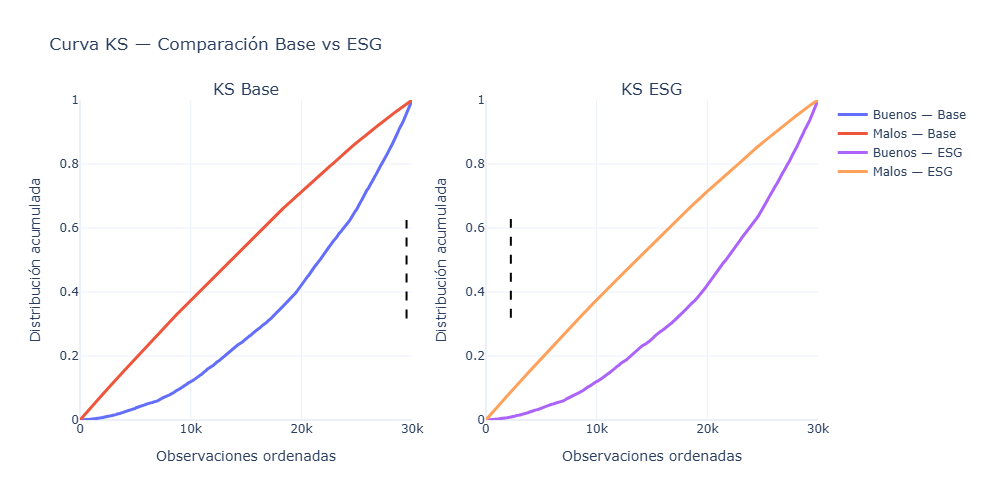

In [27]:
fig = make_subplots(rows=1, cols=2, subplot_titles=['KS Base', 'KS ESG'])

for i, (nombre, probs) in enumerate([('Base', prob_base), ('ESG', prob_esg)], 1):
    
    d = pd.DataFrame({'p': probs, 'y': y_test.values})\
            .sort_values('p', ascending=False)
    
    d['cg'] = (d['y']==0).cumsum() / (d['y']==0).sum()
    d['cb'] = (d['y']==1).cumsum() / (d['y']==1).sum()
    
    ks = (d['cb'] - d['cg']).abs()
    ks_idx = ks.idxmax()
    
    x = np.arange(len(d))
    
    # Buenos
    fig.add_trace(go.Scatter(
        x=x, y=d['cg'],
        name=f'Buenos — {nombre}',
        line=dict(width=3)
    ), row=1, col=i)
    
    # Malos
    fig.add_trace(go.Scatter(
        x=x, y=d['cb'],
        name=f'Malos — {nombre}',
        line=dict(width=3)
    ), row=1, col=i)
    
    # Línea KS
    fig.add_trace(go.Scatter(
        x=[ks_idx, ks_idx],
        y=[d.loc[ks_idx, 'cg'], d.loc[ks_idx, 'cb']],
        mode='lines',
        line=dict(dash='dash', color='black'),
        showlegend=False
    ), row=1, col=i)

fig.update_layout(
    title='Curva KS — Comparación Base vs ESG',
    width=750,
    height=500,
    template='plotly_white'
)

fig.update_yaxes(range=[0,1], title='Distribución acumulada')
fig.update_xaxes(title='Observaciones ordenadas')

fig.show()

## 8. Scorecard y decisión crediticia

In [23]:
odds_real = (train['Default']==0).sum() / (train['Default']==1).sum()

card_base = sc.scorecard(bins_base, m_base, woe_base, points0=600, odds0=odds_real, pdo=50)
card_esg  = sc.scorecard(bins_esg,  m_esg,  woe_esg,  points0=600, odds0=odds_real, pdo=50)

score_base = sc.scorecard_ply(test, card_base)
score_esg  = sc.scorecard_ply(test, card_esg)
score_base['Default'] = test['Default'].values
score_esg['Default']  = test['Default'].values

fpr, tpr, thresholds = roc_curve(y_test, -score_esg['score'])
ks = tpr - fpr
umbral_score = -thresholds[np.argmax(ks)]

score_base['Decision'] = np.where(score_base['score'] >= umbral_score, 'Aprobado', 'Rechazado')
score_esg['Decision']  = np.where(score_esg['score']  >= umbral_score, 'Aprobado', 'Rechazado')

for nombre, s in [('Base', score_base), ('ESG', score_esg)]:
    print(f'\n--- {nombre} (Umbral={umbral_score}) ---')
    print(s['Decision'].value_counts())
    print(s.groupby('Decision')['Default'].mean().round(4))


--- Base (Umbral=475.0) ---
Decision
Rechazado    16903
Aprobado     13097
Name: count, dtype: int64
Decision
Aprobado     0.7416
Rechazado    0.9116
Name: Default, dtype: float64

--- ESG (Umbral=475.0) ---
Decision
Rechazado    16873
Aprobado     13127
Name: count, dtype: int64
Decision
Aprobado     0.7418
Rechazado    0.9118
Name: Default, dtype: float64


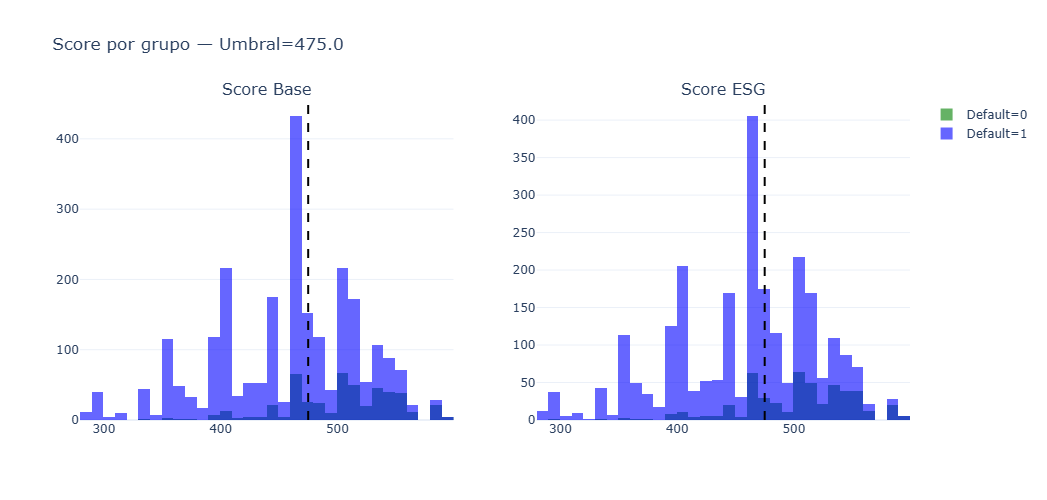

In [25]:
fig = make_subplots(rows=1, cols=2, subplot_titles=['Score Base','Score ESG'])

for i, (nombre, s) in enumerate([('Base', score_base), ('ESG', score_esg)], 1):
    for grupo, color in [(0,'green'), (1,'blue')]:
        sub = s[s['Default']==grupo]['score']
        fig.add_trace(go.Histogram(x=sub, name=f'Default={grupo}' if i==1 else '',
                                   marker_color=color, opacity=0.6, histnorm='density',
                                   showlegend=(i==1), nbinsx=40),
                      row=1, col=i)
    fig.add_vline(x=umbral_score, line_dash='dash', line_color='black', row=1, col=i)

fig.update_layout(barmode='overlay', title=f'Score por grupo — Umbral={umbral_score}',
                  template='plotly_white', width=900, height=500)
fig.show()

## 9. Validación cruzada (k=5)

In [28]:
resultados = {'Base': [], 'ESG': []}
roc_cv     = {'Base': [], 'ESG': []}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

for fold, (idx_tr, idx_te) in enumerate(skf.split(df, df['Default']), 1):
    fold_train, fold_test = df.iloc[idx_tr], df.iloc[idx_te]

    for nombre, vars_sel in [('Base', vars_base), ('ESG', vars_esg)]:
        b  = sc.woebin(fold_train[vars_sel+['Default']], y='Default', stop_limit=0.1)
        tw = sc.woebin_ply(fold_train, b)
        ew = sc.woebin_ply(fold_test,  b)
        wc = [c for c in tw.columns if c.endswith('_woe')]

        m = LogisticRegression(max_iter=1000, class_weight='balanced')
        m.fit(tw[wc], tw['Default'])

        probs = m.predict_proba(ew[wc])[:, 1]
        preds = (probs > tw['Default'].mean()).astype(int)
        auc   = roc_auc_score(ew['Default'], probs)
        tn, fp, fn, tp = confusion_matrix(ew['Default'], preds).ravel()
        fpr_f, tpr_f, _ = roc_curve(ew['Default'], probs)

        resultados[nombre].append({
            'Fold': fold, 'AUC': round(auc, 4),
            'Recall_0': round(tn/(tn+fp) if tn+fp>0 else 0, 4),
            'Recall_1': round(tp/(tp+fn) if tp+fn>0 else 0, 4),
        })
        roc_cv[nombre].append((fpr_f, tpr_f, auc))

for nombre in ['Base','ESG']:
    df_r = pd.DataFrame(resultados[nombre])
    print(f'\n--- {nombre} ---')
    print(df_r.to_string(index=False))
    print(f'AUC promedio: {df_r["AUC"].mean():.4f} ± {df_r["AUC"].std():.4f}')

[INFO] creating woe binning ...
Binning on 80000 rows and 9 columns in 00:00:20
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] creating woe binning ...
Binning on 80000 rows and 10 columns in 00:00:23
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] creating woe binning ...
Binning on 80000 rows and 9 columns in 00:00:21
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] creating woe binning ...
Binning on 80000 rows and 10 columns in 00:00:22
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] creating woe binning ...
Binning on 80000 rows and 9 columns in 00:00:22
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] creating woe binning ...
Binning on 80000 rows and 10 columns in 00:00:21
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] creating woe binning ...
Binning on 80000 rows and 9 c

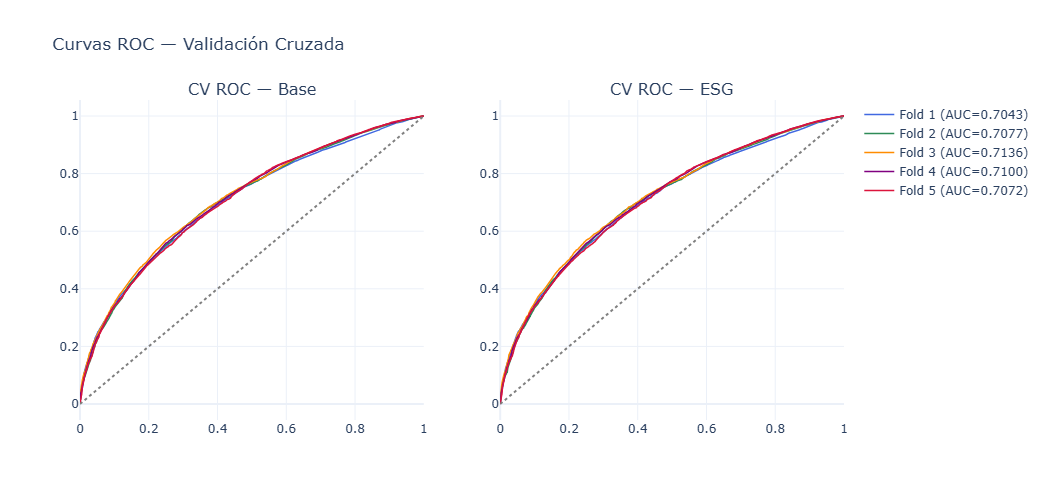

In [29]:
fig = make_subplots(rows=1, cols=2, subplot_titles=['CV ROC — Base','CV ROC — ESG'])
colores_fold = ['royalblue','seagreen','darkorange','purple','crimson']

for col_i, nombre in enumerate(['Base','ESG'], 1):
    for i, (fpr_f, tpr_f, auc_f) in enumerate(roc_cv[nombre]):
        fig.add_trace(go.Scatter(x=fpr_f, y=tpr_f, mode='lines',
                                 name=f'Fold {i+1} (AUC={auc_f:.4f})',
                                 line=dict(color=colores_fold[i], width=1.5),
                                 showlegend=(col_i==1)),
                      row=1, col=col_i)
    fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines',
                             line=dict(dash='dot', color='gray'),
                             showlegend=False), row=1, col=col_i)

fig.update_layout(title='Curvas ROC — Validación Cruzada',
                  template='plotly_white', width=900, height=500)
fig.show()